<a href="https://colab.research.google.com/github/thasnissam/NorthStar_Data_Analytics_Project/blob/main/Notebooks/Data_Analytics_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Analytics in R

####Data Integration and Importing

Library activation

In [1]:
# Load necessary libraries for manipulation and visualization
install.packages("sqldf")
library(sqldf)
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Automated Data Ingestion

In [2]:
# Define GitHub Raw path
base_url <- "https://raw.githubusercontent.com/thasnissam/NorthStar_Data_Analytics_Project/main/Data/"

# Importing datasets
customers <- read.csv(paste0(base_url, "customers.csv"))
orders <- read.csv(paste0(base_url, "orders.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))

####Data Manipulation and Transformation in R

Categorical Normalization

In [3]:
# Objective: Consolidate fragmented labels found in raw data
orders_cleaned <- orders %>%
mutate(

# Standardize Zones
pickup_zone = toupper(trimws(pickup_zone)),
dropoff_zone = toupper(trimws(dropoff_zone)),

# Resolve naming inconsistencies
pickup_zone = ifelse(pickup_zone == "CTR", "CENTRAL", pickup_zone),
dropoff_zone = ifelse(dropoff_zone == "CTR", "CENTRAL", dropoff_zone)
)

# Revenue validation after normalization
zone_check <- orders_cleaned %>%
group_by(pickup_zone) %>%
summarise(total_revenue = sum(order_value))

print(zone_check)

# A tibble: 7 × 2
  pickup_zone total_revenue
  <chr>               <dbl>
1 AIRPORT            14960.
2 CENTRAL            21051.
3 EAST               18997.
4 NORTH              15840.
5 RIVERSIDE          12886.
6 SOUTH              16396.
7 WEST               13682.


Cleaning and Feature Engineering

In [4]:
# Standardize column names and create efficiency flags
deliveries_clean <- deliveries %>%
rename(
overrides = manual_route_override_count,
satisfaction = customer_rating_post_delivery
) %>%

mutate(
cost_efficiency = ifelse(
fuel_or_charge_cost < mean(fuel_or_charge_cost),
"Efficient",
"High Cost"
)
)

Integrated Data Merging & Integrity Audit

In [5]:
# Join operational datasets
analysis_ready_df <- orders %>%
inner_join(deliveries_clean, by = "order_id") %>%
select(
order_id,
service_type,
priority_level,
fuel_or_charge_cost,
satisfaction,
overrides
)

Aggregating Service-Specific Performance

In [6]:
# Summarize service-level performance
service_summary <- analysis_ready_df %>%
group_by(service_type) %>%
summarise(
avg_cost = mean(fuel_or_charge_cost),
avg_rating = mean(satisfaction, na.rm = TRUE),
total_overrides = sum(overrides)
)

####Data Visualisation in R

Operational Reliability by Hub

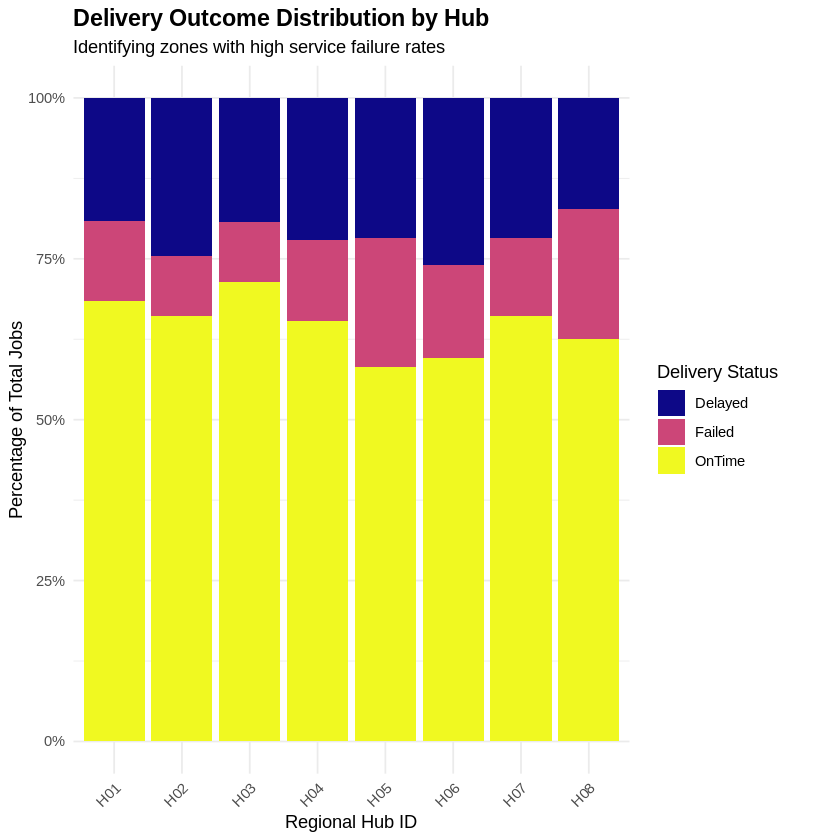

In [7]:
# Objective: Visualise delivery outcome ratios across hubs using a proportional stacked bar chart
library(ggplot2)

ggplot(deliveries, aes(x = hub_id, fill = delivery_status)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_viridis_d(option = "plasma") +
  labs(title = "Delivery Outcome Distribution by Hub",
       subtitle = "Identifying zones with high service failure rates",
       x = "Regional Hub ID",
       y = "Percentage of Total Jobs",
       fill = "Delivery Status") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(face = "bold", size = 14))

The Efficiency Gap

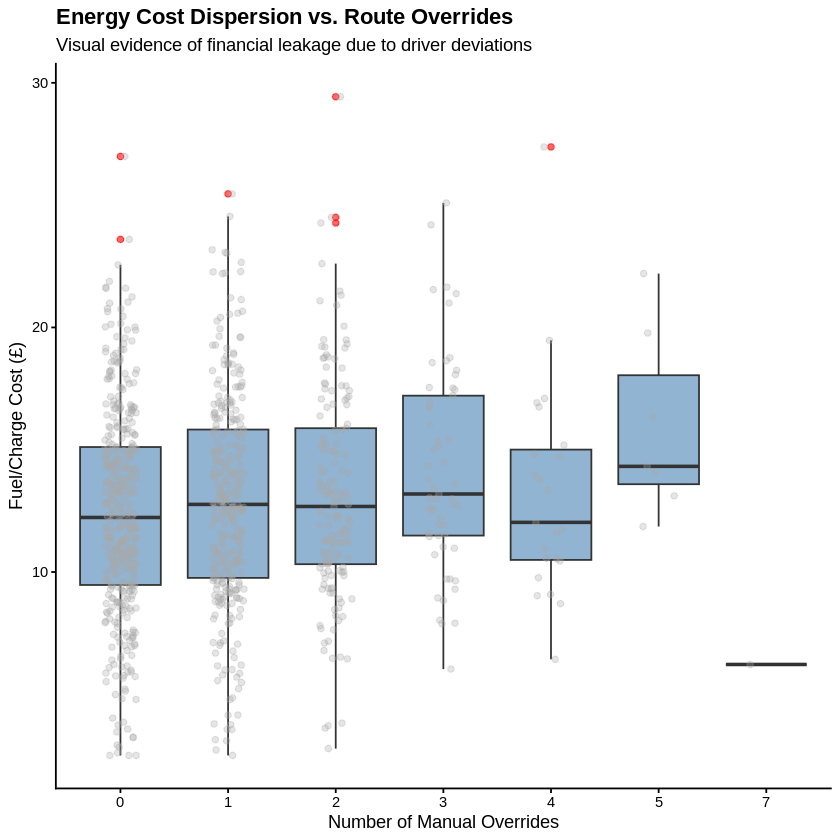

In [8]:
# Objective: Analyze the variance of energy costs relative to manual deviations
# Uses the 'deliveries_clean' data frame created in the transformation step
ggplot(deliveries_clean, aes(x = as.factor(overrides), y = fuel_or_charge_cost)) +
  geom_boxplot(fill = "steelblue", outlier.color = "red", alpha = 0.6) +
  geom_jitter(alpha = 0.3, width = 0.15, color = "darkgrey") +
  labs(title = "Energy Cost Dispersion vs. Route Overrides",
       subtitle = "Visual evidence of financial leakage due to driver deviations",
       x = "Number of Manual Overrides",
       y = "Fuel/Charge Cost (£)") +
  theme_classic() +
  theme(plot.title = element_text(face = "bold"))

Plot 3: Service Satisfaction Density

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_density()`).”


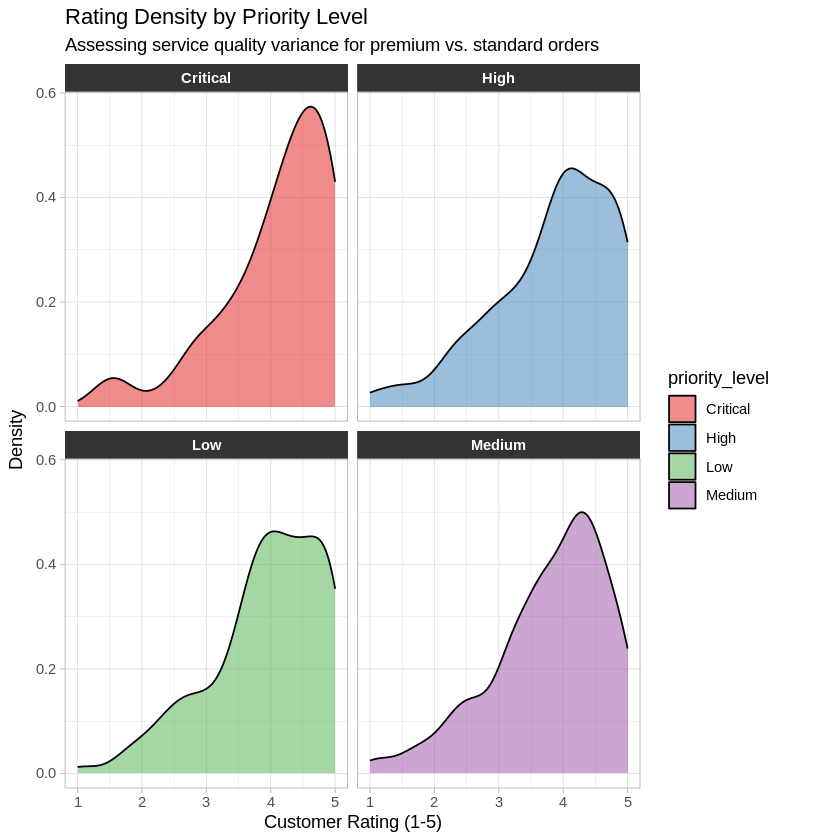

In [9]:
# Objective: View the density distribution of ratings for High vs. Low priority
# Uses 'analysis_ready_df' to link satisfaction with priority_level
ggplot(analysis_ready_df, aes(x = satisfaction, fill = priority_level)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~priority_level) +
  scale_fill_brewer(palette = "Set1") +
  labs(title = "Rating Density by Priority Level",
       subtitle = "Assessing service quality variance for premium vs. standard orders",
       x = "Customer Rating (1-5)",
       y = "Density") +
  theme_light() +
  theme(strip.background = element_rect(fill = "grey20"),
        strip.text = element_text(color = "white", face = "bold"))